In [1]:
# Fill in the wandb_id assigned to your demo run!
wandb_id = 'YOUR_ID'
if wandb_id == 'YOUR_ID':
    raise ValueError('Need to provide wandb_id of demo run!')

In [2]:
%load_ext autoreload
%autoreload 2

import os
import json
import wandb
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
# Helper Functions

def restore_file(wandb_id, filename='wandb-summary.json'):
    files_dir = 'notebooks/restored_files'    
    os.system(f'mkdir -p {files_dir}')

    api = wandb.Api()
    entity = os.getenv('WANDB_SEM_UNC_ENTITY', os.getenv('USER'))
    run = api.run(f'{entity}/semantic_uncertainty/{wandb_id}')

    path = f'{files_dir}/{filename}'
    os.system(f'rm -rf {path}')
    run.file(filename).download(root=files_dir, replace=True, exist_ok=False)
    with open(path, 'r') as f:
        out = json.load(f)
    return out

def get_perfs(metrics):
    data = []
    for method in metrics['performance']:
        mean, low, high = get_vals(metrics['performance'][method])
        data.append([method, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'means', 'low', 'high'])
    return df.set_index('method')

def get_vals(x):
    return x['mean'], x['mean'] - x['bootstrap']['std_err'], x['mean']+ x['bootstrap']['std_err']

def get_uncertainty_df(metrics):
    data = []
    for method in metrics['uncertainty']:
        for metric in metrics['uncertainty'][method]:
            mean, low, high = get_vals(metrics['uncertainty'][method][metric])
            data.append([method, metric, mean, low, high])    
    df = pd.DataFrame(data, columns=['method', 'metric', 'means', 'low', 'high'])    
    main_methods = ['regular_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy']
    df = df.set_index('method').loc[main_methods].reset_index()
    main_names = ['Regular Entropy', 'Embedding Regression', 'p(True)', 'Semantic entropy', 'Discrete Semantic Entropy']
    conversion = dict(zip(main_methods, main_names))
    df['method'] = df.method.map(lambda x: conversion[x])
    return df

In [4]:
results = restore_file(wandb_id)
name = 'trivia_qa-Llama-2-7b-chat'

In [5]:
perfs = get_perfs(results).loc['accuracy']
perfs.means

0.74

In [6]:
unc_df = get_uncertainty_df(results)

Text(0, 0.5, 'AUROC')

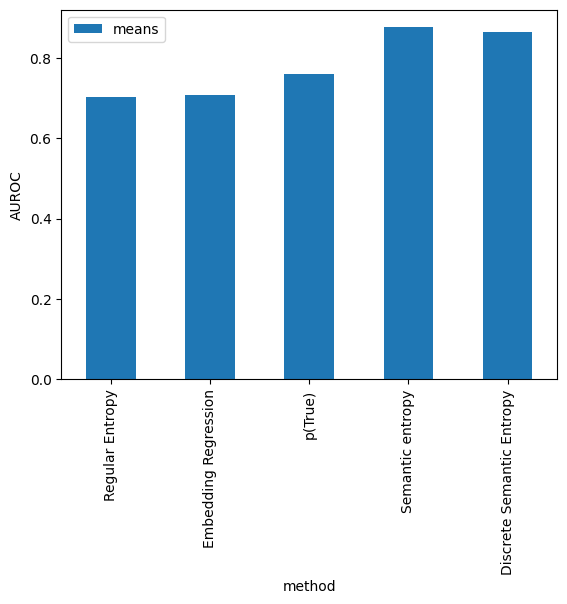

In [7]:
metric = 'AUROC'
unc_df.set_index('metric').loc[metric].plot.bar(x='method', y='means')
plt.gca().set_ylabel(metric)